In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn  as sns
from scipy import stats
import hashlib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import mlflow
import mlflow.sklearn


from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score
)

## Leitura dos dados

In [3]:
df = pd.read_excel('../data/Telco_customer_churn.xlsx')

## Visão Geral dos Dados

In [4]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

### Volume dos Dados

In [7]:
df.shape

(7043, 33)

## Qualidade dos Dados

### Nulos

In [8]:
df.isnull().sum().sort_values(ascending=False)

Churn Reason         5174
CustomerID              0
Count                   0
State                   0
Country                 0
Zip Code                0
Lat Long                0
Latitude                0
City                    0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Longitude               0
Internet Service        0
Online Security         0
Device Protection       0
Online Backup           0
Streaming TV            0
Streaming Movies        0
Contract                0
Tech Support            0
Paperless Billing       0
Payment Method          0
Total Charges           0
Monthly Charges         0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
dtype: int64

### Duplicados

In [9]:
print(df.duplicated().sum())

0



### Mudança tipagem dos dados

In [10]:
#Busquei quais eram as colunas que tinham como valor Yes e No
cols_yes_no = [
    col for col in df.columns
    if df[col].dropna().isin(['Yes', 'No']).all()
]

print("Colunas com yes/no:", cols_yes_no)

Colunas com yes/no: ['Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'Churn Label']


In [11]:
#mudar para 1 e 0
df[cols_yes_no] = df[cols_yes_no].replace({'Yes': 1, 'No': 0})

C:\Users\letic\AppData\Local\Temp\ipykernel_27024\3543961345.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_yes_no] = df[cols_yes_no].replace({'Yes': 1, 'No': 0})


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   int64  
 11  Partner            7043 non-null   int64  
 12  Dependents         7043 non-null   int64  
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   int64  
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

## Analise da variavel Target

In [13]:

df['Churn Value'].value_counts(normalize=True)

Churn Value
0    0.73463
1    0.26537
Name: proportion, dtype: float64

In [14]:
#Renomeando a minha variável target
df.rename(columns={'Churn Value': 'Churn Target'}, inplace = True)

### Desbalanceamento da variavel target

1. DISTRIBUIÇÃO DA VARIÁVEL TARGET
Churn Target
0    5174
1    1869

Ratio churn: 26.5%  |  não-churn: 73.5%


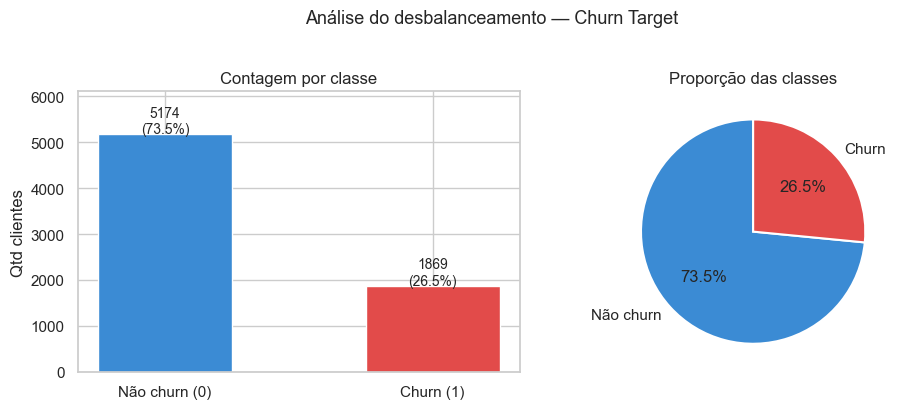


Imbalance ratio: 2.8:1


In [15]:

sns.set_theme(style="whitegrid", palette="muted")

TARGET = "Churn Target"
COLORS = ["#3B8BD4", "#E24B4A"]
LABELS = ["Não churn (0)", "Churn (1)"]


def calcular_distribuicao(df, coluna):
    counts = df[coluna].value_counts()
    pcts = df[coluna].value_counts(normalize=True) * 100
    return counts, pcts


def imprimir_resumo(counts, pcts):
    print("=" * 55)
    print("1. DISTRIBUIÇÃO DA VARIÁVEL TARGET")
    print("=" * 55)
    print(counts.to_string())
    print(f"\nRatio churn: {pcts[1]:.1f}%  |  não-churn: {pcts[0]:.1f}%")


def plotar_barras(ax, counts, pcts):
    ax.bar(LABELS, counts.values, color=COLORS, width=0.5, edgecolor="white")
    for i, (v, p) in enumerate(zip(counts.values, pcts.values)):
        ax.text(i, v + 30, f"{v}\n({p:.1f}%)", ha="center", fontsize=10)
    ax.set_title("Contagem por classe", fontsize=12)
    ax.set_ylabel("Qtd clientes")
    ax.set_ylim(0, counts.max() * 1.18)


def plotar_pizza(ax, counts):
    ax.pie(
        counts.values,
        labels=["Não churn", "Churn"],
        colors=COLORS,
        autopct="%1.1f%%",
        startangle=90,
        wedgeprops=dict(edgecolor="white", linewidth=1.5),
    )
    ax.set_title("Proporção das classes", fontsize=12)


def analisar_desbalanceamento(counts):
    ratio = counts[0] / counts[1]
    print(f"\nImbalance ratio: {ratio:.1f}:1")
    if ratio > 3:
        print("→ Dataset desbalanceado: priorizar ROC-AUC, PR-AUC e Recall.")
        print("  Considerar class_weight='balanced' ou SMOTE no pipeline.")


def analisar_target(df):
    counts, pcts = calcular_distribuicao(df, TARGET)

    imprimir_resumo(counts, pcts)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plotar_barras(axes[0], counts, pcts)
    plotar_pizza(axes[1], counts)

    plt.suptitle("Análise do desbalanceamento — Churn Target", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    analisar_desbalanceamento(counts)



analisar_target(df)

Contagem:
Churn Target
0    5174
1    1869

Percentual:
  Sem Churn: 73.46%
  Churn: 26.54%


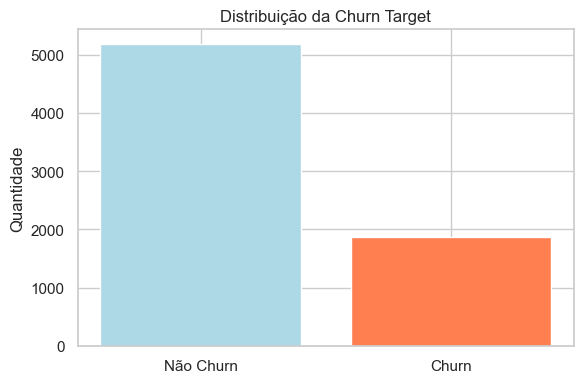

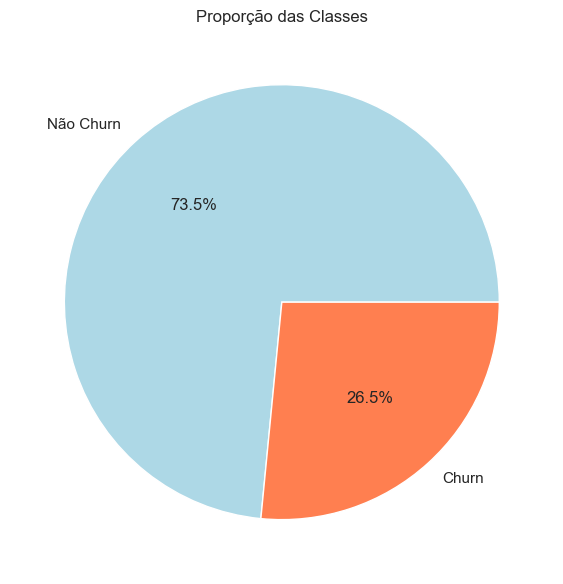


Ratio de balanceamento: 0.36 → Dataset desbalanceado


In [16]:
TARGET = "Churn Target"
LABELS = ["Não Churn", "Churn"]
COLORS = ["lightblue", "coral"]


def resumo_target(df):
    col = df[TARGET]
    contagem = col.value_counts().sort_index()
    percentual = col.value_counts(normalize=True).sort_index() * 100

    print("Contagem:")
    print(contagem.to_string())

    print("\nPercentual:")
    nomes = {0: "Sem Churn", 1: "Churn"}
    for idx, pct in percentual.items():
        print(f"  {nomes[idx]}: {pct:.2f}%")

    return contagem, percentual


def plotar_barras(contagem):
    plt.figure(figsize=(6, 4))
    plt.bar(LABELS, contagem.values, color=COLORS)
    plt.title("Distribuição da Churn Target")
    plt.ylabel("Quantidade")
    plt.tight_layout()
    plt.show()


def plotar_pizza(contagem):
    plt.figure(figsize=(6, 6))
    plt.pie(contagem.values, labels=LABELS, colors=COLORS, autopct="%1.1f%%")
    plt.title("Proporção das Classes")
    plt.tight_layout()
    plt.show()


def verificar_balanceamento(contagem):
    ratio = contagem.min() / contagem.max()
    status = "balanceado" if ratio >= 0.5 else "desbalanceado"
    print(f"\nRatio de balanceamento: {ratio:.2f} → Dataset {status}")


def analisar_churn(df):
    contagem, _ = resumo_target(df)
    plotar_barras(contagem)
    plotar_pizza(contagem)
    verificar_balanceamento(contagem)


analisar_churn(df)

### Análise de outliers

In [17]:
# ── Configurações visuais ────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
TARGET   = "Churn Target"
COR_CHURN    = "#E24B4A"   # vermelho → churnou
COR_NO_CHURN = "#3B8BD4"   # azul    → ficou
PALETTE  = {0: COR_NO_CHURN, 1: COR_CHURN}
LABELS   = {0: "Não Churn", 1: "Churn"}

In [18]:
# ── Colunas numéricas de interesse (exclui target e ids) ─────────────
num_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns
    if col != TARGET
]

print(f"Colunas numéricas analisadas ({len(num_cols)}): {num_cols}\n")

Colunas numéricas analisadas (14): ['Count', 'Zip Code', 'Latitude', 'Longitude', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Paperless Billing', 'Monthly Charges', 'Churn Label', 'Churn Score', 'CLTV']



                   outliers_IQR  outliers_Zscore       min       max     media   mediana
coluna                                                                                  
Count                         0                0      1.00      1.00      1.00      1.00
Zip Code                      0                0  90001.00  96161.00  93521.96  93552.00
Latitude                      0                0     32.56     41.96     36.28     36.39
Longitude                     0                0   -124.30   -114.19   -119.80   -119.73
Senior Citizen             1142                0      0.00      1.00      0.16      0.00
Partner                       0                0      0.00      1.00      0.48      0.00
Dependents                 1627                0      0.00      1.00      0.23      0.00
Tenure Months                 0                0      0.00     72.00     32.37     29.00
Phone Service               682              682      0.00      1.00      0.90      1.00
Paperless Billing    

C:\Users\letic\AppData\Local\Temp\ipykernel_27024\3110035423.py:14: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  fora_z = (np.abs(stats.zscore(serie)) > 3).sum()


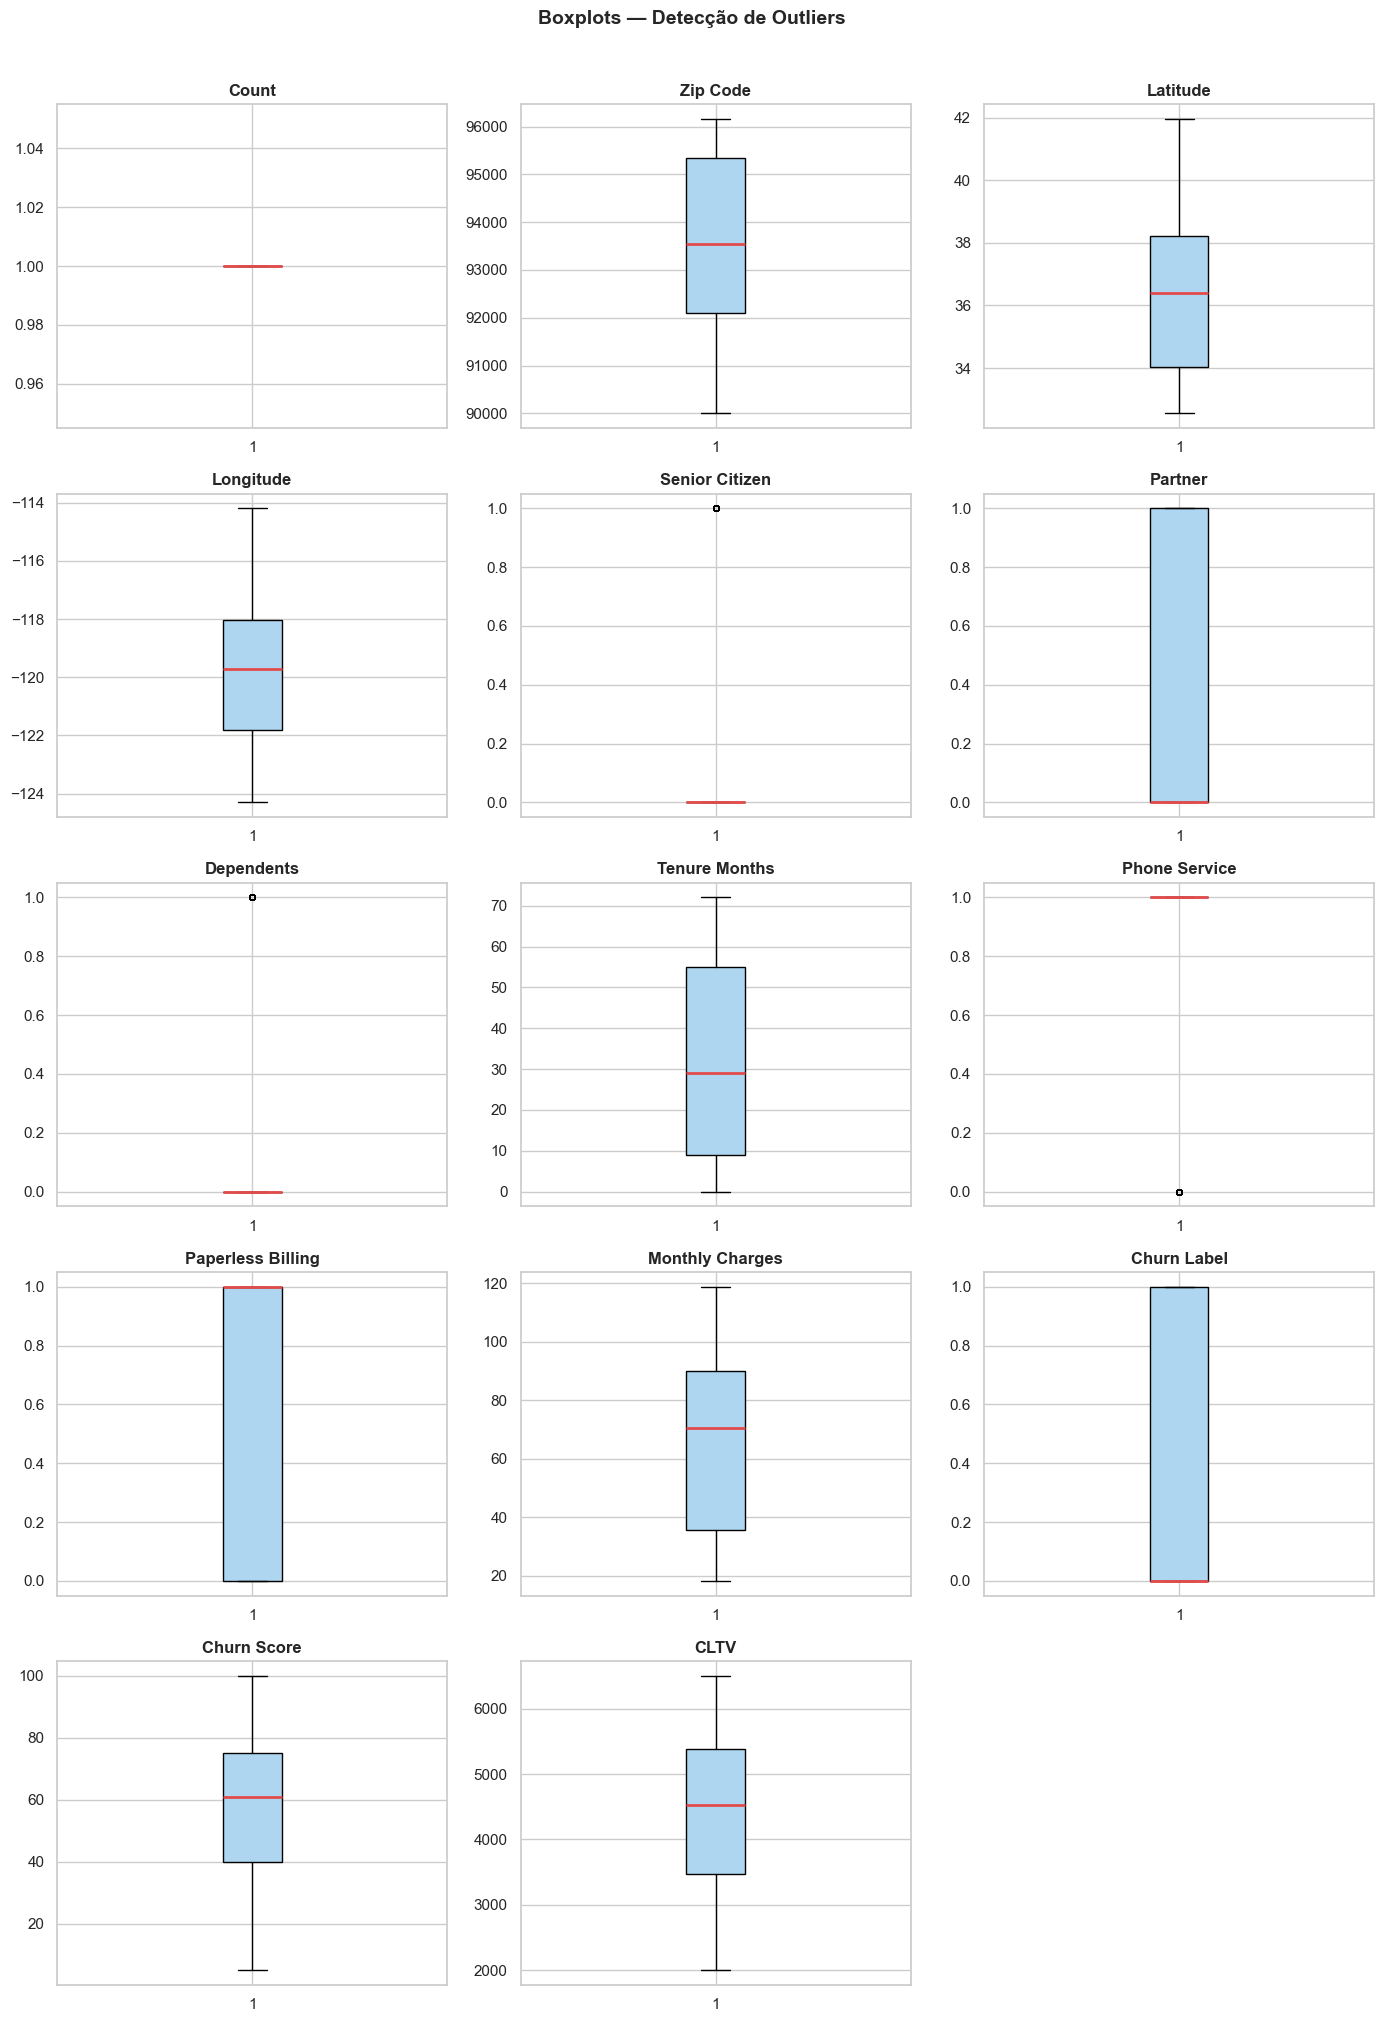

In [19]:
NCOLS = 3
BOX_STYLE = dict(
    patch_artist=True,
    boxprops=dict(facecolor="#AED6F1"),
    medianprops=dict(color="#E24B4A", linewidth=2),
    flierprops=dict(marker="o", color="#E24B4A", alpha=0.4, markersize=4),
)


def detectar_outliers(serie):
    Q1, Q3 = serie.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    fora_iqr = ((serie < Q1 - 1.5 * IQR) | (serie > Q3 + 1.5 * IQR)).sum()
    fora_z = (np.abs(stats.zscore(serie)) > 3).sum()
    return fora_iqr, fora_z


def resumo_outliers(df, num_cols):
    registros = []
    for col in num_cols:
        serie = df[col].dropna()
        n_iqr, n_z = detectar_outliers(serie)
        registros.append({
            "coluna":          col,
            "outliers_IQR":    n_iqr,
            "outliers_Zscore": n_z,
            "min":             round(serie.min(), 2),
            "max":             round(serie.max(), 2),
            "media":           round(serie.mean(), 2),
            "mediana":         round(serie.median(), 2),
        })
    return pd.DataFrame(registros).set_index("coluna")


def plotar_boxplots(df, num_cols):
    nrows = int(np.ceil(len(num_cols) / NCOLS))
    fig, axes = plt.subplots(nrows, NCOLS, figsize=(14, 4 * nrows))

    for ax, col in zip(axes.ravel(), num_cols):
        ax.boxplot(df[col].dropna(), **BOX_STYLE)
        ax.set_title(col, fontweight="bold")

    for ax in axes.ravel()[len(num_cols):]:
        ax.set_visible(False)

    plt.suptitle("Boxplots — Detecção de Outliers", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def analisar_outliers(df, num_cols):
    df_outliers = resumo_outliers(df, num_cols)
    print(df_outliers.to_string())
    plotar_boxplots(df, num_cols)


analisar_outliers(df, num_cols)

### Análise de Distribuição das Variáveis Numéricas

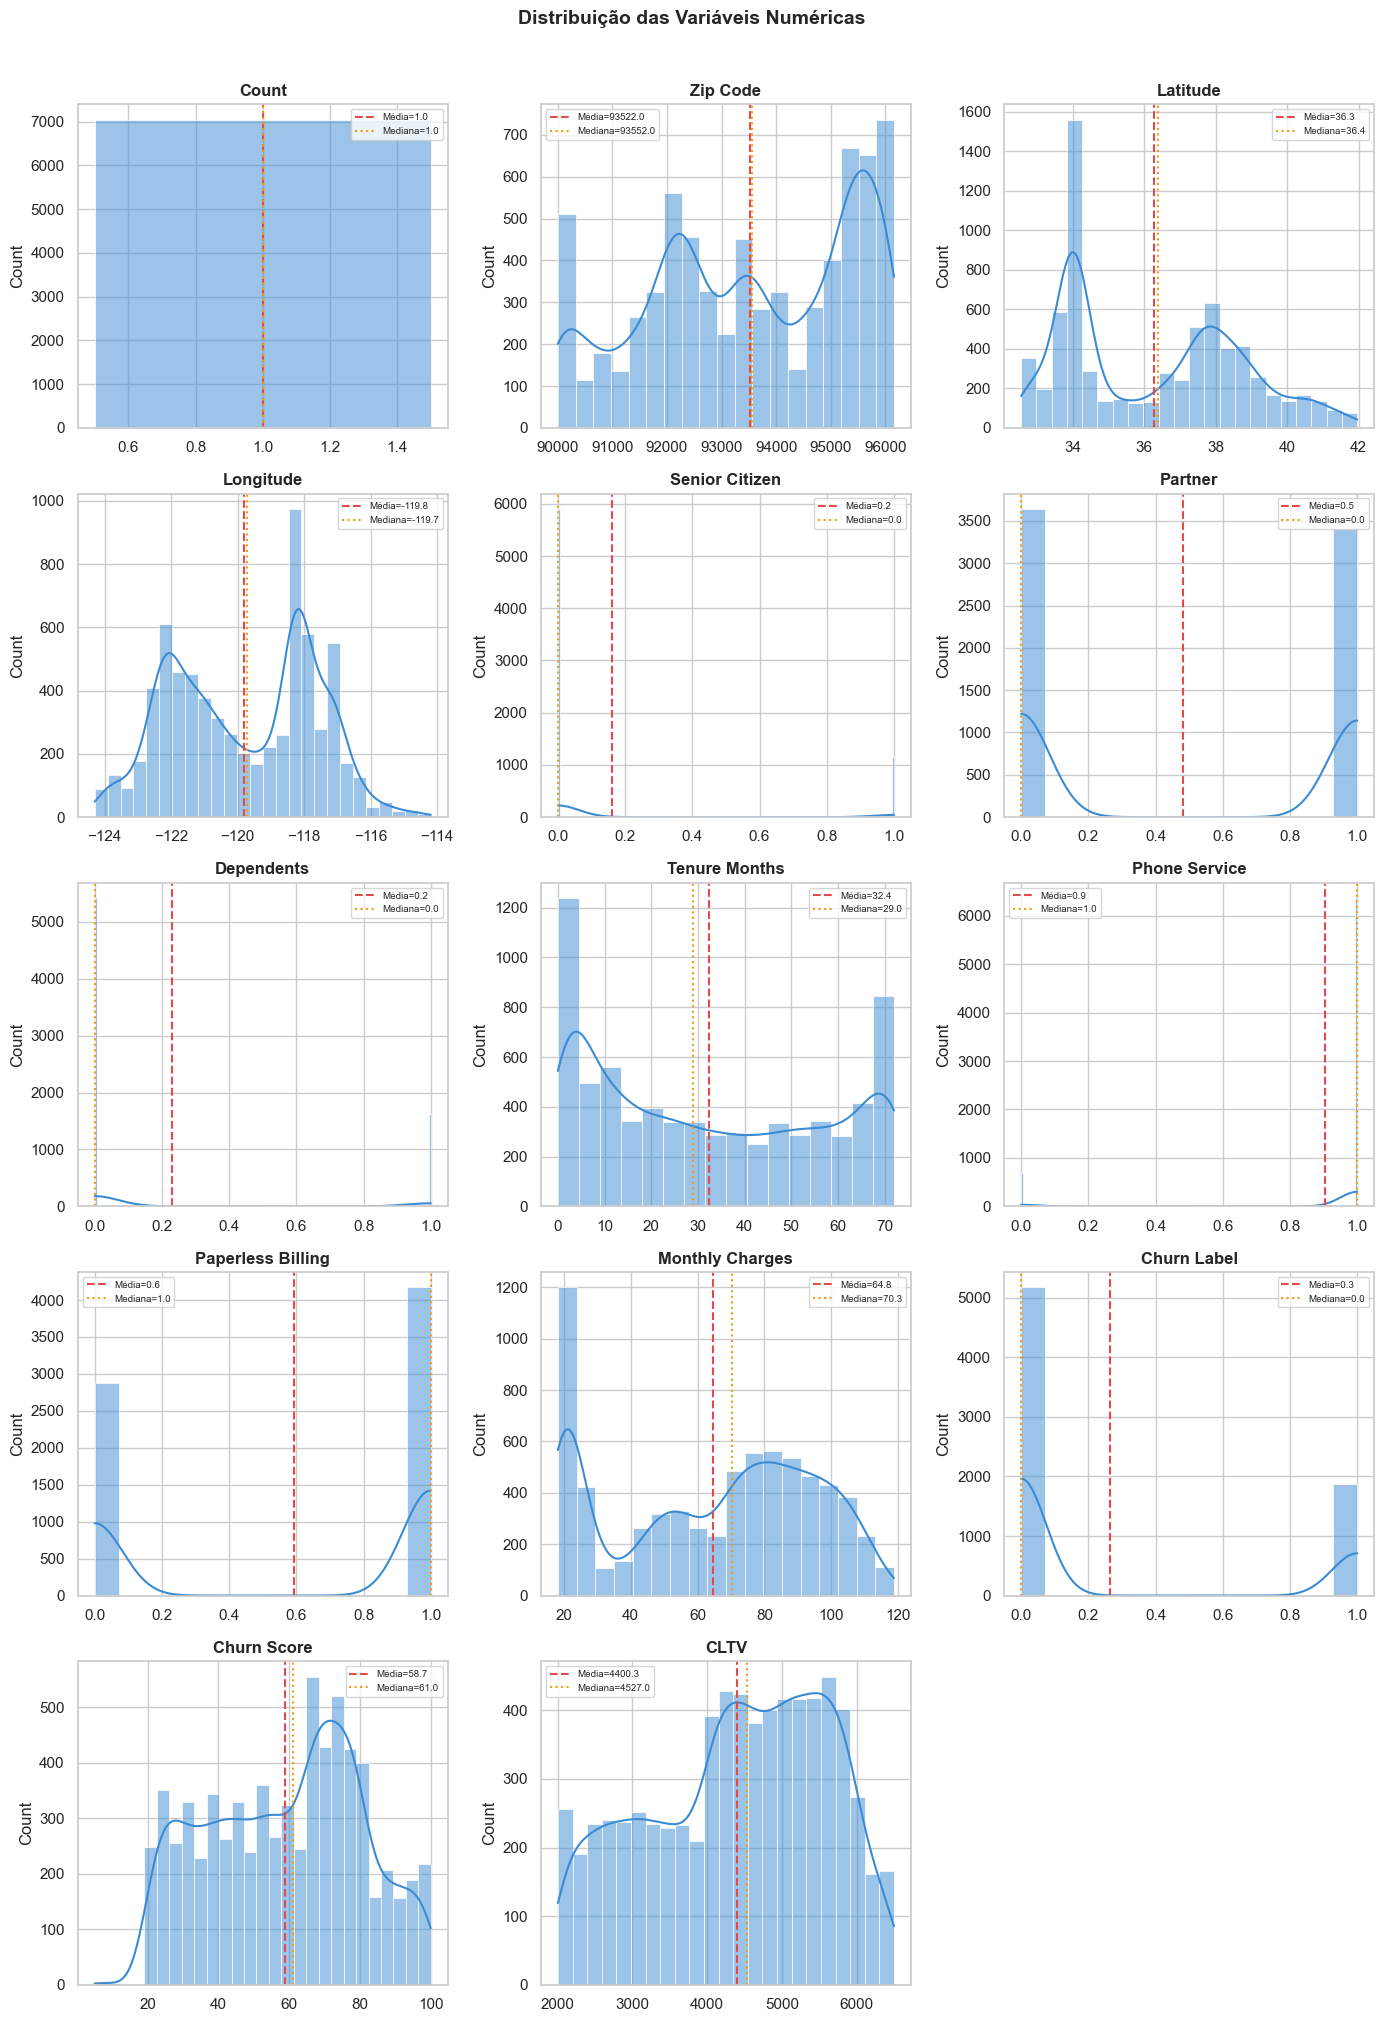


Assimetria (skewness) e Curtose por coluna:
  Count                               skew=    0.0  kurtosis=    0.0  
  Zip Code                            skew= -0.251  kurtosis= -1.154  
  Latitude                            skew=  0.304  kurtosis= -1.136  
  Longitude                           skew= -0.041  kurtosis= -1.136  
  Senior Citizen                      skew=  1.834  kurtosis=  1.363  ⚠️  assimétrica
  Partner                             skew=  0.068  kurtosis= -1.996  
  Dependents                          skew=  1.277  kurtosis=  -0.37  ⚠️  assimétrica
  Tenure Months                       skew=   0.24  kurtosis= -1.387  
  Phone Service                       skew= -2.727  kurtosis=  5.439  ⚠️  assimétrica
  Paperless Billing                   skew= -0.375  kurtosis=  -1.86  
  Monthly Charges                     skew= -0.221  kurtosis= -1.257  
  Churn Label                         skew=  1.063  kurtosis=  -0.87  ⚠️  assimétrica
  Churn Score                         skew=

In [20]:
NCOLS = 3
HIST_STYLE    = dict(color="#3B8BD4", edgecolor="white", linewidth=0.5)
LINHA_MEDIA   = dict(color="#E24B4A", linestyle="--", linewidth=1.5)
LINHA_MEDIANA = dict(color="#F39C12", linestyle=":",  linewidth=1.5)


def plotar_histograma(ax, serie, col):
    sns.histplot(serie, kde=True, ax=ax, **HIST_STYLE)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("")

    media, mediana = serie.mean(), serie.median()
    ax.axvline(media,   **LINHA_MEDIA,   label=f"Média={media:.1f}")
    ax.axvline(mediana, **LINHA_MEDIANA, label=f"Mediana={mediana:.1f}")
    ax.legend(fontsize=7)


def plotar_distribuicoes(df, num_cols, ncols=NCOLS):
    nrows = int(np.ceil(len(num_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))

    for ax, col in zip(axes.ravel(), num_cols):
        plotar_histograma(ax, df[col].dropna(), col)

    for ax in axes.ravel()[len(num_cols):]:
        ax.set_visible(False)

    plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()


def imprimir_assimetria(df, num_cols):
    print("\nAssimetria (skewness) e Curtose por coluna:")
    for col in num_cols:
        sk = round(df[col].skew(), 3)
        ku = round(df[col].kurt(), 3)
        flag = "⚠️  assimétrica" if abs(sk) > 1 else ""
        print(f"  {col:<35} skew={sk:>7}  kurtosis={ku:>7}  {flag}")


def analisar_distribuicoes(df, num_cols):
    plotar_distribuicoes(df, num_cols)
    imprimir_assimetria(df, num_cols)


analisar_distribuicoes(df, num_cols)

### Análise bivariada: numéroca vs Target

C:\Users\letic\AppData\Local\Temp\ipykernel_27024\4194655492.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([g0, g1], **BOX_STYLE)
C:\Users\letic\AppData\Local\Temp\ipykernel_27024\4194655492.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([g0, g1], **BOX_STYLE)
C:\Users\letic\AppData\Local\Temp\ipykernel_27024\4194655492.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([g0, g1], **BOX_STYLE)
C:\Users\letic\AppData\Local\Temp\ipykernel_27024\4194655492.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' s

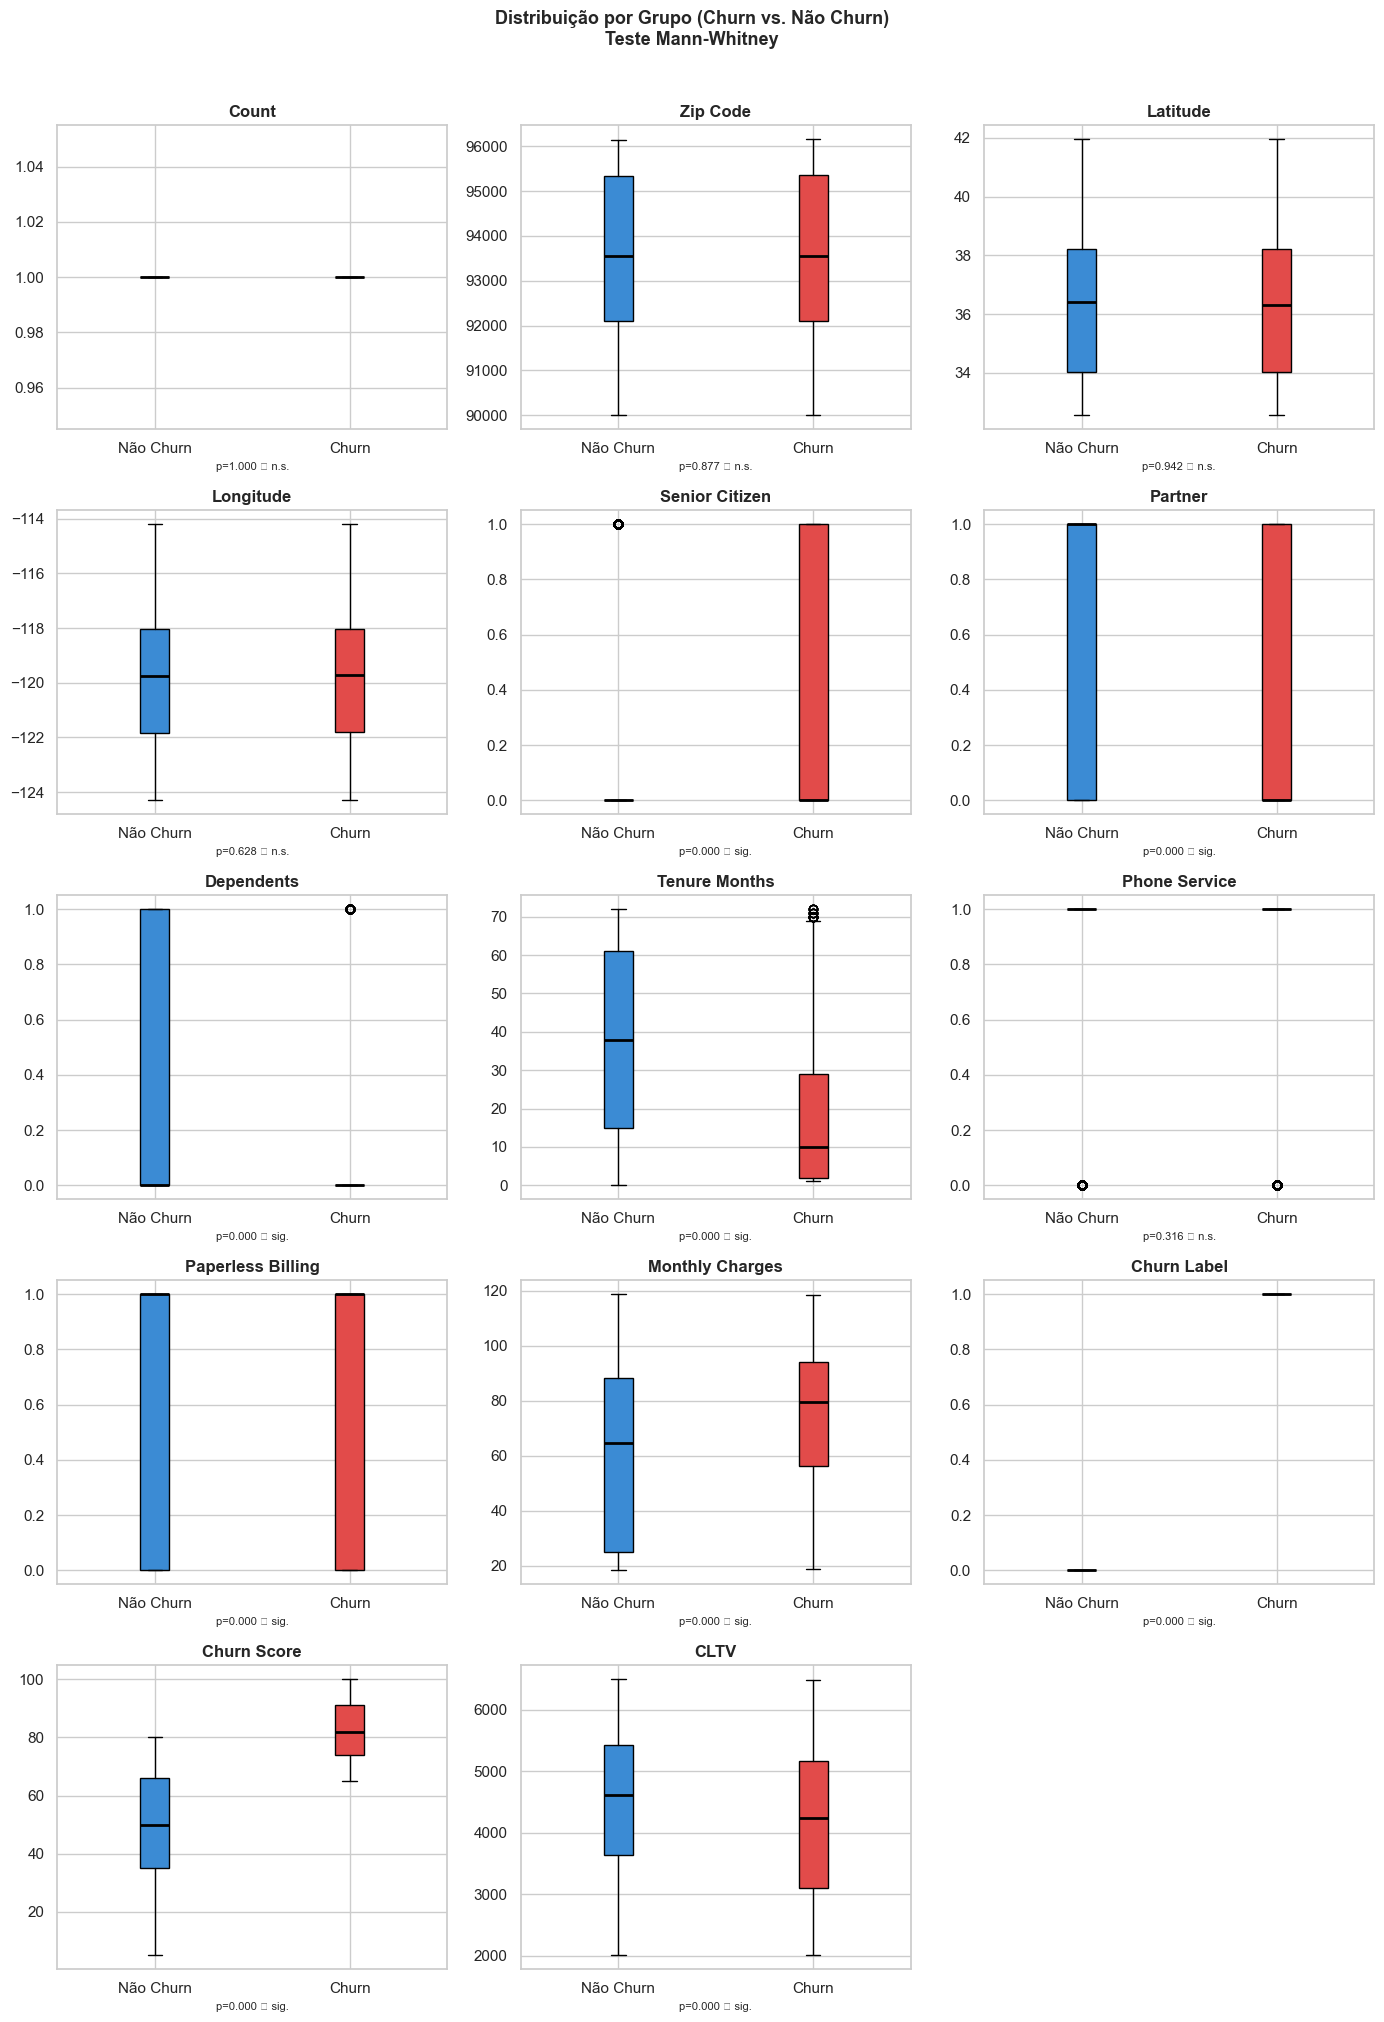


Média por grupo e diferença relativa (Churn vs. Não Churn):
                   media_no_churn  media_churn        diff_%  p_value significativo
feature                                                                            
Churn Label                  0.00         1.00  1.000000e+11   0.0000             ✅
Senior Citizen               0.13         0.25  9.790000e+01   0.0000             ✅
Dependents                   0.29         0.06 -8.070000e+01   0.0000             ✅
Churn Score                 50.10        82.51  6.470000e+01   0.0000             ✅
Tenure Months               37.57        17.98 -5.210000e+01   0.0000             ✅
Paperless Billing            0.54         0.75  3.990000e+01   0.0000             ✅
Partner                      0.53         0.36 -3.220000e+01   0.0000             ✅
Monthly Charges             61.27        74.44  2.150000e+01   0.0000             ✅
CLTV                      4490.92      4149.41 -7.600000e+00   0.0000             ✅
Phone Service  

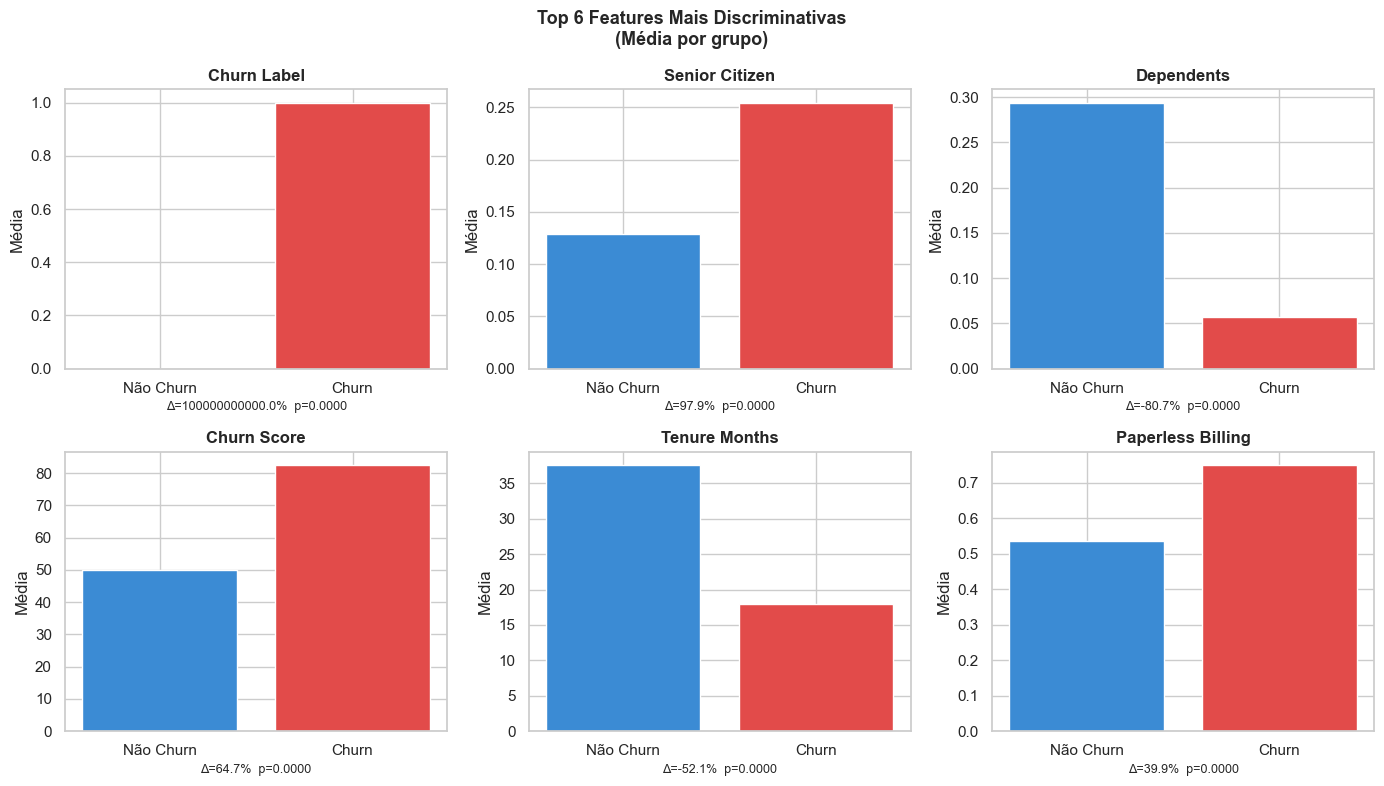

In [21]:
NCOLS = 3
BOX_STYLE = dict(
    patch_artist=True,
    labels=["Não Churn", "Churn"],
    boxprops=dict(facecolor="#AED6F1"),
    medianprops=dict(color="black", linewidth=2),
)


# ── Helpers ──────────────────────────────────────────────────────

def grupos_por_target(df, col):
    return [df.loc[df[TARGET] == v, col].dropna() for v in [0, 1]]


def teste_mann_whitney(g0, g1):
    stat, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    return p


def plotar_boxplot_grupo(ax, df, col):
    g0, g1 = grupos_por_target(df, col)
    bp = ax.boxplot([g0, g1], **BOX_STYLE)
    bp["boxes"][0].set_facecolor(COR_NO_CHURN)
    bp["boxes"][1].set_facecolor(COR_CHURN)
    ax.set_title(col, fontweight="bold")

    p = teste_mann_whitney(g0, g1)
    sig = "✅ sig." if p < 0.05 else "❌ n.s."
    ax.set_xlabel(f"p={p:.3f} {sig}", fontsize=8)


# ── 3a. Boxplots por grupo ────────────────────────────────────────

def plotar_boxplots_grupos(df, num_cols, ncols=NCOLS):
    nrows = int(np.ceil(len(num_cols) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))

    for ax, col in zip(axes.ravel(), num_cols):
        plotar_boxplot_grupo(ax, df, col)

    for ax in axes.ravel()[len(num_cols):]:
        ax.set_visible(False)

    plt.suptitle(
        "Distribuição por Grupo (Churn vs. Não Churn)\nTeste Mann-Whitney",
        fontsize=13, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.show()


# ── 3b. Tabela de médias e diferença relativa ─────────────────────

def calcular_tabela_bivariada(df, num_cols):
    registros = []
    for col in num_cols:
        g0, g1 = grupos_por_target(df, col)
        m0, m1 = g0.mean(), g1.mean()
        diff = (m1 - m0) / (m0 + 1e-9) * 100
        p = teste_mann_whitney(g0, g1)
        registros.append({
            "feature":        col,
            "media_no_churn": round(m0, 2),
            "media_churn":    round(m1, 2),
            "diff_%":         round(diff, 1),
            "p_value":        round(p, 4),
            "significativo":  "✅" if p < 0.05 else "❌",
        })

    df_biv = (
        pd.DataFrame(registros)
        .set_index("feature")
        .sort_values("diff_%", key=abs, ascending=False)
    )
    print("\nMédia por grupo e diferença relativa (Churn vs. Não Churn):")
    print(df_biv.to_string())
    return df_biv


# ── 3c. Barras — top 6 features mais discriminativas ─────────────

def plotar_top_features(df, df_biv, top_n=6):
    top_cols = df_biv.head(top_n).index.tolist()
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    for ax, col in zip(axes.ravel(), top_cols):
        medias = df.groupby(TARGET)[col].mean()
        ax.bar(["Não Churn", "Churn"], [medias[0], medias[1]],
               color=[COR_NO_CHURN, COR_CHURN], edgecolor="white")
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Média")
        ax.set_xlabel(
            f"Δ={df_biv.loc[col, 'diff_%']:.1f}%  p={df_biv.loc[col, 'p_value']:.4f}",
            fontsize=9,
        )

    plt.suptitle("Top 6 Features Mais Discriminativas\n(Média por grupo)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()


# ── Execução ──────────────────────────────────────────────────────

def analisar_bivariada(df, num_cols):
    plotar_boxplots_grupos(df, num_cols)
    df_biv = calcular_tabela_bivariada(df, num_cols)
    plotar_top_features(df, df_biv)


analisar_bivariada(df, num_cols)

### Análise de Correlação

In [22]:
#separa as colunas em categorias e numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])


In [23]:
num_cols

['Count',
 'Zip Code',
 'Latitude',
 'Longitude',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Paperless Billing',
 'Monthly Charges',
 'Churn Label',
 'Churn Score',
 'CLTV']

In [24]:

corr = df_numerico.corr()
for coluna in corr.columns:
    if coluna != 'Churn Target':
        valor = corr.loc[coluna, 'Churn Target']
        print(coluna, ":", round(valor, 2))

Count : nan
Zip Code : 0.0
Latitude : -0.0
Longitude : 0.0
Senior Citizen : 0.15
Partner : -0.15
Dependents : -0.25
Tenure Months : -0.35
Phone Service : 0.01
Paperless Billing : 0.19
Monthly Charges : 0.19
Churn Label : 1.0
Churn Score : 0.66
CLTV : -0.13


## Tratamento de Dados

### Drop Colunas Numéricas Com Pouca Relação

In [25]:

colunas_num_remover = [
    'Count',        # Constante = 1 para todos os registros
    'Zip Code',     # Alta cardinalidade (1.652 CEPs), redundante
    'Latitude',     # Alto ruído sem feature engineering espacial
    'Longitude',    # Alto ruído sem feature engineering espacial
    'Churn Score',  # Score derivado do churn — não disponível em produção
    'CLTV',         # Calculado com histórico completo, inclui info pós-churn
    'Total Charges',# Derivada de Monthly Charges × Tenure Months
    'Churn Label'   # Repetição do Target
]

df = df.drop(columns=colunas_num_remover)


In [26]:

colunas_cat_remover = [
    'CustomerID',   # ID único por cliente — sem valor preditivo
    'Country',      # Valor único: "United States" em 100% dos registros
    'State',        # Valor único: "California" em 100% dos registros
    'City',         # Alta cardinalidade (1.129 cidades), Lat/Long já cobrem
    'Lat Long',     # String composta que duplica Latitude e Longitude
    'Churn Reason' # Preenchido APENAS para quem já cancelou — leakage direto
]

df = df.drop(columns=colunas_cat_remover)



In [27]:
print("\nShape após drop categórico:", df.shape)
print("\nColunas restantes:")
for col in df.columns:
    print("-", col)


Shape após drop categórico: (7043, 19)

Colunas restantes:
- Gender
- Senior Citizen
- Partner
- Dependents
- Tenure Months
- Phone Service
- Multiple Lines
- Internet Service
- Online Security
- Online Backup
- Device Protection
- Tech Support
- Streaming TV
- Streaming Movies
- Contract
- Paperless Billing
- Payment Method
- Monthly Charges
- Churn Target


## Enconding

In [28]:
#Criando novo dataset para preseravar os dados
data = df.copy()

In [29]:
#one hot encoding nas colunas categóricas
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
cat_cols = data.select_dtypes(include=['object']).columns

df_encoded = pd.get_dummies(data, columns= cat_cols, drop_first=True)

df_encoded.shape
df_encoded.head()

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Churn Target,Gender_Male,Multiple Lines_No phone service,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,0,0,0,2,1,1,53.85,1,True,False,...,False,False,False,False,False,False,False,False,False,True
1,0,0,1,2,1,1,70.70,1,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,0,1,8,1,1,99.65,1,False,False,...,False,False,True,False,True,False,False,False,True,False
3,0,1,1,28,1,1,104.80,1,False,False,...,True,False,True,False,True,False,False,False,True,False
4,0,0,1,49,1,1,103.70,1,True,False,...,False,False,True,False,True,False,False,False,False,False


In [30]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Senior Citizen                          7043 non-null   int64  
 1   Partner                                 7043 non-null   int64  
 2   Dependents                              7043 non-null   int64  
 3   Tenure Months                           7043 non-null   int64  
 4   Phone Service                           7043 non-null   int64  
 5   Paperless Billing                       7043 non-null   int64  
 6   Monthly Charges                         7043 non-null   float64
 7   Churn Target                            7043 non-null   int64  
 8   Gender_Male                             7043 non-null   bool   
 9   Multiple Lines_No phone service         7043 non-null   bool   
 10  Multiple Lines_Yes                      7043 non-null   bool

## Métricas

Devido ao desbalanceamento típico em problemas de churn, adotamos PR-AUC como métrica principal, pois ela fornece uma avaliação mais fiel da performance na classe minoritária, conforme demonstrado por Saito & Rehmsmeier 2015 e Davis & Goadrich 2006.

Complementarmente, utilizamos o F1-score para otimização do threshold, uma vez que essa métrica equilibra precision e recall, sendo amplamente recomendada em cenários com classes desbalanceadas, conforme He & Garcia 2009.

Por fim, o ROC-AUC foi mantido como métrica secundária para comparação com a literatura, dado seu uso consolidado na avaliação de classificadores binários, conforme Tom Fawcett 2006, apesar de suas limitações em cenários desbalanceados.

Finalmente, traduzimos o desempenho do modelo em valor de negócio por meio do cálculo de churn evitado, alinhando a solução com impacto financeiro direto.

Valor de Negócio=(TP × LTV × taxa_retenção)−((TP+FP) × custo_retenção)

## Split dos Dados

In [ ]:
X = df_encoded.drop(columns=['Churn Target'])
y = df_encoded['Churn Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

#Criando um conjunto de validação a partir do conjunto de teste que vai ser usado no early stopping
X_val, X_test, y_val, y_test = train_test_split(
    X_test, y_test, test_size=0.50, random_state=42, stratify=y_test
)


In [32]:
print(f"Treino:    {len(X_train)} amostras ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validação: {len(X_val)} amostras ({len(X_val)/len(X)*100:.1f}%)")
print(f"Teste:     {len(X_test)} amostras ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nX_train linhas: {len(X_train)} | y_train linhas: {len(y_train)}")
print(f"X_val linhas:   {len(X_val)}   | y_val linhas:   {len(y_val)}")
print(f"X_test linhas:  {len(X_test)}  | y_test linhas:  {len(y_test)}")

Treino:    5282 amostras (75.0%)
Validação: 880 amostras (12.5%)
Teste:     881 amostras (12.5%)

X_train linhas: 5282 | y_train linhas: 5282
X_val linhas:   880   | y_val linhas:   880
X_test linhas:  881  | y_test linhas:  881


## Dados Normalizados com StandardScaler pra RL

In [33]:
# scaler fitado apenas no treino para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_val_scaled   = scaler.transform(X_val) # validação para os dados do mlp

## Validação Cruzada

In [34]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = LogisticRegression(random_state=42, max_iter=1000)
cv_scores = cross_val_score(lr_cv, X_train_scaled, y_train,
                             cv=kf, scoring='roc_auc')
print(f"\nCV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


CV ROC-AUC: 0.8558 ± 0.0073


## Hash

In [35]:
# Gera um hash reproduzível do dataset final
dataset_hash = hashlib.md5(
    pd.util.hash_pandas_object(df_encoded, index=True).values
).hexdigest()

dataset_meta = {
    "dataset_rows":     len(df_encoded),
    "dataset_features": X_train.shape[1],
    "train_size":       len(X_train),
    "test_size":        len(X_test),
    "churn_rate_pct":   round(y.mean() * 100, 2),
    "dataset_hash":     dataset_hash,
}

print("Dataset metadata:")
for k, v in dataset_meta.items():
    print(f"  {k}: {v}")

Dataset metadata:
  dataset_rows: 7043
  dataset_features: 29
  train_size: 5282
  test_size: 881
  churn_rate_pct: 26.54
  dataset_hash: c5a66f0e5e1912f4a9b3981a11e2756d


## Baselines


### Dummy Classifier

In [36]:
def calcular_metricas(y_true, y_pred, y_proba):
    return {
        "accuracy":  accuracy_score(y_true, y_pred),
        "f1_score":  f1_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall":    recall_score(y_true, y_pred),
        "roc_auc":   roc_auc_score(y_true, y_proba),
        "pr_auc":    average_precision_score(y_true, y_proba),
    }

In [37]:
mlflow.end_run()
mlflow.set_experiment("Telco-Churn")

with mlflow.start_run(run_name="dummy_baseline"):
    mlflow.log_params(dataset_meta)

    dummy = DummyClassifier(strategy="most_frequent", random_state=42)
    dummy.fit(X_train_scaled, y_train)  # alterado

    y_pred_dummy  = dummy.predict(X_test_scaled)       # alterado
    y_proba_dummy = dummy.predict_proba(X_test_scaled)[:, 1]  # alterado

    metricas_dummy = calcular_metricas(y_test, y_pred_dummy, y_proba_dummy)

    mlflow.log_metrics(metricas_dummy)
    mlflow.sklearn.log_model(dummy, "model")

    print("=== DUMMY CLASSIFIER ===")
    for nome, valor in metricas_dummy.items():
        print(f"  {nome:<16}: {valor:.4f}")

c:\Users\letic\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
2026/04/28 23:16:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 23:16:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


=== DUMMY CLASSIFIER ===
  accuracy        : 0.7162
  f1_score        : 0.0000
  precision       : 0.0000
  recall          : 0.0000
  roc_auc         : 0.5000
  pr_auc          : 0.2838


<Axes: >

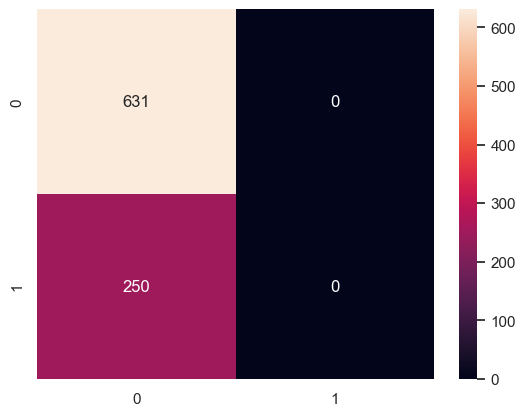

In [38]:
matriz_dummy = confusion_matrix(y_test, y_pred_dummy)
sns.heatmap(matriz_dummy, annot=True,  fmt="d")

### Regressão Logística

In [39]:
mlflow.end_run()
mlflow.set_experiment("Telco-Churn")

with mlflow.start_run(run_name="logistic_regression_baseline"):
    mlflow.log_params(dataset_meta)

    lr = LogisticRegression(random_state=42, max_iter=1000)
    lr.fit(X_train_scaled, y_train)

    y_pred_train_lr = lr.predict(X_train_scaled)
    y_pred_lr       = lr.predict(X_test_scaled)
    y_proba_lr      = lr.predict_proba(X_test_scaled)[:, 1]

    metricas_lr = calcular_metricas(y_test, y_pred_lr, y_proba_lr)
    metricas_lr["train_accuracy"] = accuracy_score(y_train, y_pred_train_lr)
    metricas_lr["overfitting"]    = metricas_lr["train_accuracy"] - metricas_lr["accuracy"]

    mlflow.log_metrics(metricas_lr)
    mlflow.sklearn.log_model(lr, "model")

    print("\n=== LOGISTIC REGRESSION ===")
    for nome, valor in metricas_lr.items():
        print(f"  {nome:<16}: {valor:.4f}")

2026/04/28 23:16:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 23:16:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== LOGISTIC REGRESSION ===
  accuracy        : 0.8138
  f1_score        : 0.6511
  precision       : 0.6955
  recall          : 0.6120
  roc_auc         : 0.8601
  pr_auc          : 0.7193
  train_accuracy  : 0.8156
  overfitting     : 0.0018


<Axes: >

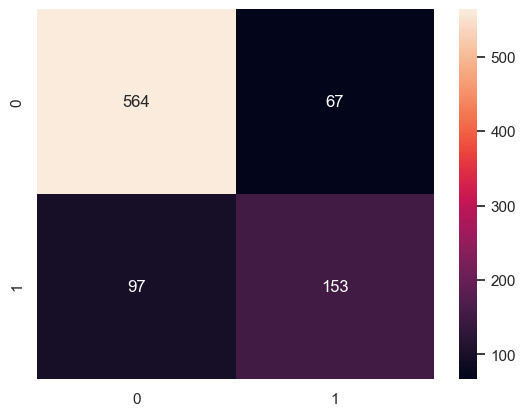

In [40]:
matriz_log = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(matriz_log, annot=True,  fmt="d")

# Etapa 2

In [41]:
import torch
import torch.nn as nn

In [42]:
X_train_np = np.array(X_train_scaled).astype(float)
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float)

X_test_np = np.array(X_test_scaled).astype(float)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float)

X_val_np     = np.array(X_val_scaled).astype(float)
X_val_tensor = torch.tensor(X_val_np, dtype=torch.float)

In [43]:
y_train_np = np.array(y_train).astype(float)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float)

y_test_np = np.array(y_test).astype(float)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float)

y_val_np     = np.array(y_val).astype(float)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float)

In [44]:
print(type(X_train_tensor))
print(type(X_test_tensor))

<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [45]:
print((X_train_tensor).shape)
print((y_train_tensor).shape)

torch.Size([5282, 29])
torch.Size([5282])


In [46]:
#Pra ficar igual o formato do X_train_tensor, que tem 2 dimensões, e o y_train_tensor, que tem 1 dimensão, a gente precisa adicionar uma dimensão extra no y_train_tensor usando unsqueeze(1)
y_train_tensor = y_train_tensor.unsqueeze(1)

In [47]:
dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)

In [48]:
type(dataset)

torch.utils.data.dataset.TensorDataset

In [49]:
train_loader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)

## Construção do Modelo

In [50]:
val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor.unsqueeze(1))
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=10)
EPOCHS    = 10000
PATIENCE  = 10
LR        = 0.001

#Quantos neuronios na entrada
input_dim  = X_train_scaled.shape[1]
hidden_dim = input_dim // 2 # qtd de neuronios na camada oculta

In [51]:
print(input_dim)
print(hidden_dim)

29
14


In [52]:
mlflow.end_run()
mlflow.set_experiment("Telco-Churn")

with mlflow.start_run(run_name="mlp_pytorch"):
    mlflow.log_params(dataset_meta)
    mlflow.log_params({
        "arquitetura":   f"{input_dim}-{hidden_dim}-{hidden_dim}-1",
        "ativacao":      "ReLU",
        "loss_function": "BCELoss",
        "optimizer":     "Adam",
        "learning_rate": LR,
        "batch_size":    10,
        "patience":      PATIENCE,
        "max_epochs":    EPOCHS,
    })

    classificador = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 1),
        nn.Sigmoid()
    )

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(classificador.parameters(), lr=LR, weight_decay=0.0001)

    best_val_loss = float('inf')
    counter       = 0
    epoca_parada  = 0

    for epoch in range(EPOCHS):
        # Treino
        classificador.train()
        train_loss = 0.0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs    = classificador(inputs)
            loss       = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validação
        classificador.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs   = classificador(inputs)
                loss      = criterion(outputs, labels)
                val_loss += loss.item()
        val_loss /= len(val_loader)

        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss",   val_loss,   step=epoch)
        print(f"Época {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early Stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter       = 0
            epoca_parada  = epoch + 1
            torch.save(classificador.state_dict(), "best_mlp.pt")
        else:
            counter += 1

        if counter >= PATIENCE:
            print(f"Early stopping ativado na época {epoch+1}")
            break

    mlflow.log_param("epoca_parada",   epoca_parada)
    mlflow.log_metric("best_val_loss", best_val_loss)

    # Avaliação final
    classificador.load_state_dict(torch.load("best_mlp.pt"))
    classificador.eval()

    with torch.no_grad():
        proba_mlp = classificador(X_test_tensor).numpy().flatten()

    for t in [0.3, 0.4, 0.5]:
        pred_t = (proba_mlp >= t).astype(int)
        print(f"\n--- Threshold {t} ---")
        print(f"  F1:        {f1_score(y_test, pred_t):.4f}")
        print(f"  Precision: {precision_score(y_test, pred_t):.4f}")
        print(f"  Recall:    {recall_score(y_test, pred_t):.4f}")

    THRESHOLD = 0.4
    pred_mlp  = (proba_mlp >= THRESHOLD).astype(int)

    metricas_mlp = calcular_metricas(y_test, pred_mlp, proba_mlp)
    mlflow.log_metrics(metricas_mlp)
    mlflow.log_artifact("best_mlp.pt")

    print("\n=== MLP PYTORCH ===")
    for nome, valor in metricas_mlp.items():
        print(f"  {nome:<16}: {valor:.4f}")
    print(f"\n  Melhor Val Loss: {best_val_loss:.4f} (época {epoca_parada})")

    

Época 1 | Train Loss: 0.4703 | Val Loss: 0.4448
Época 2 | Train Loss: 0.4068 | Val Loss: 0.4356
Época 3 | Train Loss: 0.4015 | Val Loss: 0.4308
Época 4 | Train Loss: 0.3979 | Val Loss: 0.4288
Época 5 | Train Loss: 0.3951 | Val Loss: 0.4258
Época 6 | Train Loss: 0.3923 | Val Loss: 0.4238
Época 7 | Train Loss: 0.3908 | Val Loss: 0.4223
Época 8 | Train Loss: 0.3884 | Val Loss: 0.4252
Época 9 | Train Loss: 0.3859 | Val Loss: 0.4248
Época 10 | Train Loss: 0.3853 | Val Loss: 0.4204
Época 11 | Train Loss: 0.3839 | Val Loss: 0.4202
Época 12 | Train Loss: 0.3822 | Val Loss: 0.4256
Época 13 | Train Loss: 0.3817 | Val Loss: 0.4212
Época 14 | Train Loss: 0.3798 | Val Loss: 0.4249
Época 15 | Train Loss: 0.3793 | Val Loss: 0.4192
Época 16 | Train Loss: 0.3797 | Val Loss: 0.4200
Época 17 | Train Loss: 0.3795 | Val Loss: 0.4204
Época 18 | Train Loss: 0.3772 | Val Loss: 0.4213
Época 19 | Train Loss: 0.3765 | Val Loss: 0.4280
Época 20 | Train Loss: 0.3767 | Val Loss: 0.4221
Época 21 | Train Loss: 0.3750

<Axes: >

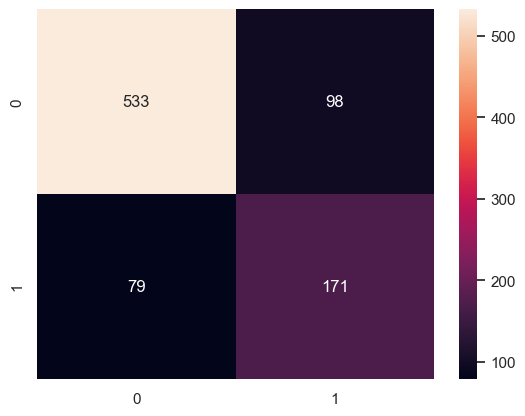

In [53]:
matriz_mlp = confusion_matrix(y_test, pred_mlp)

sns.heatmap(matriz_mlp, annot=True, fmt="d" )

### GridSearch
Para saber qual é a melhor profundidade para as árvores de decisão e random forest

In [ ]:

#Para saber qual é a melhor profundidade para as árvores de decisão e random forest

param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None]
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,                # validação cruzada com 5 folds
    scoring='roc_auc',   # métrica que você quer otimizar
    n_jobs=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"Melhor max_depth: {grid_search.best_params_}")
print(f"Melhor ROC-AUC:   {grid_search.best_score_:.4f}")

# GridSearch para Random Forest
grid_forest = GridSearchCV(
    RandomForestClassifier(n_estimators=40, random_state=42),
    param_grid,
    cv=5, scoring='roc_auc', n_jobs=1
)
grid_forest.fit(X_train, y_train)
print(f"Melhor RF: {grid_forest.best_params_}")

Melhor max_depth: {'max_depth': 5}
Melhor ROC-AUC:   0.8307
Melhor RF: {'max_depth': 7}


### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

mlflow.end_run()

with mlflow.start_run(run_name="decision_tree_baseline"):
    mlflow.log_params(dataset_meta)

    tree = DecisionTreeClassifier(max_depth=7, random_state=42)
    tree.fit(X_train_scaled, y_train)

    y_pred_train_tree = tree.predict(X_train_scaled)
    y_pred_test_tree = tree.predict(X_test_scaled)
    y_proba_test_tree = tree.predict_proba(X_test_scaled)[:, 1]

    metricas_tree = calcular_metricas(y_test, y_pred_test_tree, y_proba_test_tree)
    metricas_tree["train_accuracy"] = accuracy_score(y_train, y_pred_train_tree)
    metricas_tree["overfitting"]    = metricas_tree["train_accuracy"] - metricas_tree["accuracy"]

    mlflow.log_metrics(metricas_tree)
    mlflow.sklearn.log_model(tree, "model")

    print("\n=== DECISION TREE ===")
    for nome, valor in metricas_tree.items():
        print(f"  {nome:<16}: {valor:.4f}")

2026/04/28 23:17:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 23:17:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== DECISION TREE ===
  accuracy        : 0.7991
  f1_score        : 0.6040
  precision       : 0.6853
  recall          : 0.5400
  roc_auc         : 0.8264
  pr_auc          : 0.6426
  train_accuracy  : 0.8262
  overfitting     : 0.0271


<Axes: >

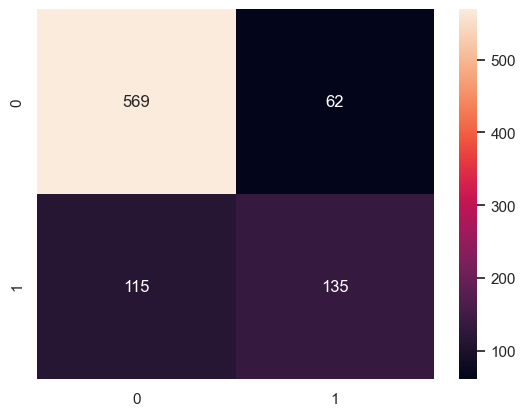

In [56]:
matriz_decision_tree = confusion_matrix(y_test, y_pred_test_tree)
sns.heatmap(matriz_decision_tree, annot=True,fmt="d")

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

mlflow.end_run()

with mlflow.start_run(run_name="random_forest_baseline"):
    mlflow.log_params(dataset_meta)

    forest = RandomForestClassifier(n_estimators=40, max_depth=15, criterion='entropy', random_state=42)
    forest.fit(X_train_scaled, y_train)

    y_pred_train_forest = forest.predict(X_train_scaled)
    y_pred_test_forest = forest.predict(X_test_scaled)
    y_proba_test_forest = forest.predict_proba(X_test_scaled)[:, 1]

    metricas_forest = calcular_metricas(y_test, y_pred_test_forest, y_proba_test_forest)
    metricas_forest["train_accuracy"] = accuracy_score(y_train, y_pred_train_forest)
    metricas_forest["overfitting"]    = metricas_forest["train_accuracy"] - metricas_forest["accuracy"]

    mlflow.log_metrics(metricas_forest)
    mlflow.sklearn.log_model(forest, "model")

    print("\n=== RANDOM FOREST ===")
    for nome, valor in metricas_forest.items():
        print(f"  {nome:<16}: {valor:.4f}")

2026/04/28 23:17:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/28 23:17:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== RANDOM FOREST ===
  accuracy        : 0.8138
  f1_score        : 0.6388
  precision       : 0.7108
  recall          : 0.5800
  roc_auc         : 0.8438
  pr_auc          : 0.6770
  train_accuracy  : 0.9756
  overfitting     : 0.1617


<Axes: >

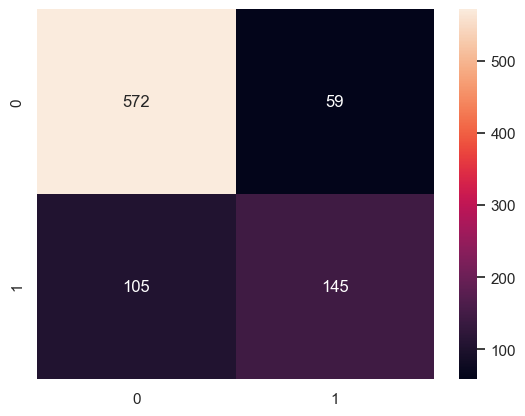

In [58]:
matriz_random_forest = confusion_matrix(y_test, y_pred_test_forest)
sns.heatmap(matriz_random_forest, annot=True, fmt="d")


## Tabela de comparação

In [59]:

df_runs = mlflow.search_runs(experiment_names=["Telco-Churn"])

colunas = [
    "tags.mlflow.runName",
    "start_time",
    "metrics.accuracy",
    "metrics.f1_score",
    "metrics.precision",
    "metrics.recall",
    "metrics.roc_auc",
    "metrics.pr_auc",
]

df_comparacao = df_runs[colunas].copy()
df_comparacao.columns = ["modelo", "start_time", "accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]

df_comparacao = df_comparacao.dropna(subset=["roc_auc"])

df_comparacao = (
    df_comparacao
    .sort_values("start_time", ascending=False)
    .drop_duplicates(subset=["modelo"], keep="first")
    .drop(columns=["start_time"])
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

# ── Impressão visual ──────────────────────────────────────────────────────────
metricas = ["accuracy", "f1_score", "precision", "recall", "roc_auc", "pr_auc"]
melhores = {col: df_comparacao[col].max() for col in metricas}

COL_MODELO = 28
COL_MET    = 11
BARRA      = "═" * (COL_MODELO + COL_MET * len(metricas) + 1)
cabecalhos = ["accuracy", "f1", "precision", "recall", "roc_auc", "pr_auc"]

print(f"\n{'COMPARAÇÃO DE MODELOS — Telco Churn':^{len(BARRA)}}")
print(BARRA)
print(f"{'modelo':<{COL_MODELO}}" + "".join(f"{h:>{COL_MET}}" for h in cabecalhos))
print("─" * len(BARRA))

for _, row in df_comparacao.iterrows():
    linha = f"{row['modelo']:<{COL_MODELO}}"
    for col in metricas:
        val = row[col]
        cel = f"{val:.4f}"
        # marca o melhor valor de cada coluna com ★
        if val == melhores[col]:
            cel = f"{cel}★"
        linha += f"{cel:>{COL_MET}}"
    print(linha)

print(BARRA)
print(f"  ★ melhor valor por coluna")
print()

# ranking final por roc_auc
melhor = df_comparacao.iloc[0]
print(f"  🏆 Melhor modelo  : {melhor['modelo']}")
print(f"     ROC-AUC        : {melhor['roc_auc']:.4f}")
print(f"     F1             : {melhor['f1_score']:.4f}")
print(f"     Recall         : {melhor['recall']:.4f}")



                              COMPARAÇÃO DE MODELOS — Telco Churn                              
═══════════════════════════════════════════════════════════════════════════════════════════════
modelo                         accuracy         f1  precision     recall    roc_auc     pr_auc
───────────────────────────────────────────────────────────────────────────────────────────────
mlp_pytorch                      0.7991     0.6590     0.6357     0.6840    0.8611★     0.7184
logistic_regression_baseline    0.8138★     0.6511     0.6955     0.6120     0.8601    0.7193★
clean-crane-350                  0.7900    0.6593★     0.6109    0.7160★     0.8566     0.7015
random_forest_baseline          0.8138★     0.6388    0.7108★     0.5800     0.8438     0.6770
decision_tree_baseline           0.7991     0.6040     0.6853     0.5400     0.8264     0.6426
dummy_baseline                   0.7162     0.0000     0.0000     0.0000     0.5000     0.2838
══════════════════════════════════════════════

## Trade Off


Modelo                       FP    FN     Custo FP     Custo FN     Resultado
---------------------------------------------------------------------------
Dummy                         0   250  R$        0  R$  125,000  R$  -125,000
Regressão Logística          67    97  R$    3,350  R$   48,500  R$   -36,550
Decision Tree                62   115  R$    3,100  R$   57,500  R$   -47,100
Random Forest                59   105  R$    2,950  R$   52,500  R$   -40,950
MLP PyTorch                  98    79  R$    4,900  R$   39,500  R$   -27,300


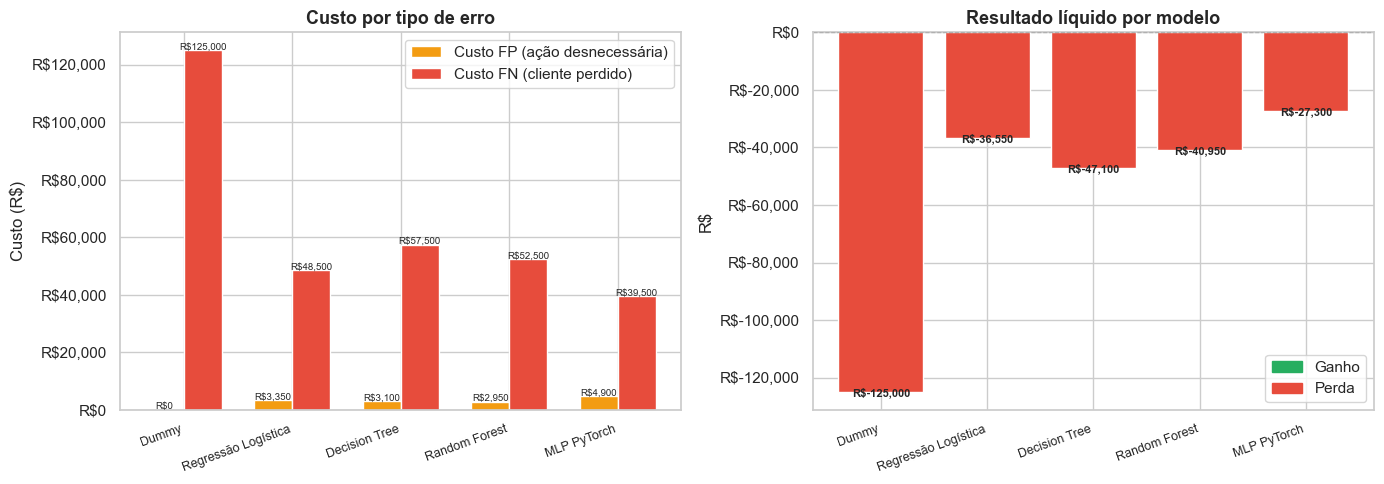


🏆 Melhor modelo financeiramente : MLP PyTorch
   Resultado líquido estimado    : R$ -27,300.00
   FP (ações desnecessárias)     : 98 clientes → R$ 4,900.00
   FN (clientes perdidos)        : 79 clientes → R$ 39,500.00


In [60]:
#PARÂMETROS DE NEGÓCIO
LTV            = 500   # receita perdida por cliente que cancela
CUSTO_RETENCAO = 50    # custo de abordar um cliente (desconto, ligação...)
TAXA_RETENCAO  = 0.30  # % de clientes que ficam quando abordados

# FUNÇÃO DE CUSTO
def calcular_custo(y_true, y_pred, ltv, custo_retencao, taxa_retencao):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    ganho_vp  = tp * (taxa_retencao * ltv - custo_retencao)  # reteve e ganhou
    custo_fp  = fp * custo_retencao                          # abordou à toa
    custo_fn  = fn * ltv                                     # perdeu o cliente
    resultado = ganho_vp - custo_fp - custo_fn

    return {
        "VP": int(tp), "FP": int(fp), "FN": int(fn), "VN": int(tn),
        "ganho_VP": round(ganho_vp, 2),
        "custo_FP": round(custo_fp, 2),
        "custo_FN": round(custo_fn, 2),
        "resultado": round(resultado, 2),
    }

#MATRIZES De Confusão
def values_cm(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

models = {
    "Dummy":               values_cm(y_test, y_pred_dummy),
    "Regressão Logística": values_cm(y_test, y_pred_lr),
    "Decision Tree":       values_cm(y_test, y_pred_test_tree),
    "Random Forest":       values_cm(y_test, y_pred_test_forest),
    "MLP PyTorch":         values_cm(y_test, pred_mlp),
}

#CALCULAR RESULTADO FINANCEIRO DE CADA MODELO 
resultados = []
for nome, m in models.items():
    y_true = np.array([0]*m["tn"] + [0]*m["fp"] + [1]*m["fn"] + [1]*m["tp"])
    y_pred = np.array([0]*m["tn"] + [1]*m["fp"] + [0]*m["fn"] + [1]*m["tp"])
    r = calcular_custo(y_true, y_pred, LTV, CUSTO_RETENCAO, TAXA_RETENCAO)
    r["modelo"] = nome
    resultados.append(r)

#TABELA NO CONSOLE
print(f"\n{'Modelo':<25} {'FP':>5} {'FN':>5}  {'Custo FP':>11}  {'Custo FN':>11}  {'Resultado':>12}")
print("-" * 75)
for r in resultados:
    print(f"{r['modelo']:<25} {r['FP']:>5} {r['FN']:>5}  "
          f"R$ {r['custo_FP']:>8,.0f}  R$ {r['custo_FN']:>8,.0f}  R$ {r['resultado']:>9,.0f}")

#GRÁFICOS
nomes     = [r["modelo"] for r in resultados]
custo_fp  = [r["custo_FP"] for r in resultados]
custo_fn  = [r["custo_FN"] for r in resultados]
resultado = [r["resultado"] for r in resultados]
x         = np.arange(len(nomes))
w         = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — Custo FP vs FN por modelo
ax1 = axes[0]
b1 = ax1.bar(x - w/2, custo_fp, w, label="Custo FP (ação desnecessária)", color="#F39C12")
b2 = ax1.bar(x + w/2, custo_fn, w, label="Custo FN (cliente perdido)",    color="#E74C3C")
ax1.set_title("Custo por tipo de erro", fontsize=13, fontweight="bold")
ax1.set_xticks(x)
ax1.set_xticklabels(nomes, rotation=20, ha="right", fontsize=9)
ax1.set_ylabel("Custo (R$)")
ax1.legend()
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R${v:,.0f}"))
for b in list(b1) + list(b2):
    h = b.get_height()
    ax1.text(b.get_x() + b.get_width()/2, h + 200, f"R${h:,.0f}", ha="center", fontsize=7)

# Gráfico 2 — Resultado líquido por modelo
ax2 = axes[1]
cores = ["#27AE60" if v >= 0 else "#E74C3C" for v in resultado]
barras = ax2.bar(nomes, resultado, color=cores, edgecolor="white")
ax2.set_title("Resultado líquido por modelo", fontsize=13, fontweight="bold")
ax2.set_xticks(range(len(nomes)))
ax2.set_xticklabels(nomes, rotation=20, ha="right", fontsize=9)
ax2.set_ylabel("R$")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"R${v:,.0f}"))
ax2.legend(handles=[mpatches.Patch(color="#27AE60", label="Ganho"),
                    mpatches.Patch(color="#E74C3C", label="Perda")])
for b in barras:
    h = b.get_height()
    ax2.text(b.get_x() + b.get_width()/2, h + (300 if h >= 0 else -1500),
             f"R${h:,.0f}", ha="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

#CONCLUSÃO
melhor = max(resultados, key=lambda r: r["resultado"])
print(f"\n🏆 Melhor modelo financeiramente : {melhor['modelo']}")
print(f"   Resultado líquido estimado    : R$ {melhor['resultado']:,.2f}")
print(f"   FP (ações desnecessárias)     : {melhor['FP']} clientes → R$ {melhor['custo_FP']:,.2f}")
print(f"   FN (clientes perdidos)        : {melhor['FN']} clientes → R$ {melhor['custo_FN']:,.2f}")